# Qwen Judge — GPU Run (Windows WSL + NVIDIA)

Runs `src/judge.py` directly using the **Ollama backend** with GPU acceleration.  
Output: `outputs/ratings_judge.jsonl` (9,600 rows)

**Open this notebook with:**
```bash
conda activate applesVsOranges
cd /mnt/d/ApplesVSOranges
jupyter notebook run_judge.ipynb
```

---
## Sections
1. GPU verification
2. Install Ollama & pull model *(one-time)*
3. Start Ollama daemon with GPU
4. Run the judge
5. Inspect results
6. Compare vs paper's Qwen-72B baseline

---
## Section 1 — GPU Verification

In [1]:
# 1a. Check nvidia-smi is visible inside WSL
# If this fails, your Windows NVIDIA driver needs updating (>=527.41)
# or you are on WSL1 — switch to WSL2.
!nvidia-smi

/bin/bash: /home/khois345/miniconda3/lib/libtinfo.so.6: no version information available (required by /bin/bash)
Mon May 11 12:53:31 2026       
+-----------------------------------------------------------------------------------------+
| NVIDIA-SMI 590.57                 Driver Version: 591.86         CUDA Version: 13.1     |
+-----------------------------------------+------------------------+----------------------+
| GPU  Name                 Persistence-M | Bus-Id          Disp.A | Volatile Uncorr. ECC |
| Fan  Temp   Perf          Pwr:Usage/Cap |           Memory-Usage | GPU-Util  Compute M. |
|                                         |                        |               MIG M. |
|=========================================+========================+======================|
|   0  NVIDIA GeForce RTX 3090        On  |   00000000:01:00.0  On |                  N/A |
| 53%   43C    P3            108W /  390W |    1907MiB /  24576MiB |     42%      Default |
|                          

In [2]:
# 1b. Check PyTorch sees the GPU
import torch

print(f"PyTorch : {torch.__version__}")
print(f"CUDA    : {torch.cuda.is_available()}")

if torch.cuda.is_available():
    print(f"GPU     : {torch.cuda.get_device_name(0)}")
    print(f"VRAM    : {torch.cuda.get_device_properties(0).total_memory / 1e9:.1f} GB")
    torch.zeros(1).cuda()   # quick allocation test
    print("GPU tensor test: PASSED")
else:
    print("ERROR: PyTorch cannot see your GPU.")
    print("Re-install PyTorch with CUDA:")
    print("pip install torch --index-url https://download.pytorch.org/whl/cu121")

PyTorch : 2.11.0+cu130
CUDA    : True
GPU     : NVIDIA GeForce RTX 3090
VRAM    : 25.8 GB
GPU tensor test: PASSED


---
## Section 2 — Install Ollama & Pull Model *(one-time)*

In [3]:
# If Ollama is not installed, open a WSL terminal (not this notebook) and run:
#   curl -fsSL https://ollama.com/install.sh | sh
# Then come back here and verify:
import shutil
path = shutil.which("ollama")
print("Ollama found at:", path) if path else print("ERROR: ollama not found — install it in your WSL terminal first.")

Ollama found at: /usr/local/bin/ollama


In [4]:
# Pull the model (~4.4 GB, one-time)
MODEL = "qwen2.5:7b-instruct-q4_K_M"
print(f"Pulling {MODEL} ...")
!ollama pull {MODEL}

Pulling qwen2.5:7b-instruct-q4_K_M ...
/bin/bash: /home/khois345/miniconda3/lib/libtinfo.so.6: no version information available (required by /bin/bash)
]11;?\pulling manifest ⠋ pulling manifest ⠙ pulling manifest ⠹ pulling manifest ⠸ pulling manifest ⠼ pulling manifest 
pulling 2bada8a74506: 100% ▕██████████████████▏ 4.7 GB                         
pulling 66b9ea09bd5b: 100% ▕██████████████████▏   68 B                         
pulling eb4402837c78: 100% ▕██████████████████▏ 1.5 KB                         
pulling 832dd9e00a68: 100% ▕██████████████████▏  11 KB                         
pulling 2f15b3218f05: 100% ▕██████████████████▏  487 B                         
verifying sha256 digest 
writing manifest 
success 


---
## Section 3 — Start Ollama Daemon with GPU

In [5]:
# Start ollama with GPU env vars set
# OLLAMA_NUM_GPU=-1  → load ALL model layers onto GPU
# CUDA_VISIBLE_DEVICES=0  → use first GPU

import os, subprocess, time, requests

OLLAMA_URL = "http://localhost:11434"

def ollama_is_running():
    try:
        requests.get(f"{OLLAMA_URL}/api/tags", timeout=3)
        return True
    except Exception:
        return False

if ollama_is_running():
    print("Ollama is already running on port 11434")
else:
    env = os.environ.copy()
    env["OLLAMA_NUM_GPU"]      = "-1"
    env["CUDA_VISIBLE_DEVICES"] = "0"
    subprocess.Popen(["ollama", "serve"], env=env,
                     stdout=subprocess.DEVNULL, stderr=subprocess.DEVNULL)
    print("Waiting for daemon ...")
    for i in range(20):
        time.sleep(1)
        if ollama_is_running():
            print(f"Ollama ready (took {i+1}s)")
            break
    else:
        print("Daemon did not respond. Open a WSL terminal and run 'ollama serve' manually.")

Ollama is already running on port 11434


In [6]:
# Warm-up call to load model into VRAM, then confirm GPU usage
MODEL = "qwen2.5:7b-instruct-q4_K_M"

resp = requests.post(
    f"{OLLAMA_URL}/v1/chat/completions",
    json={"model": MODEL,
          "messages": [{"role": "user", "content": "Reply with the number 3 only."}],
          "max_tokens": 5},
    timeout=120,
)
print("Warm-up response:", resp.json()["choices"][0]["message"]["content"])
print()

# ollama ps shows VRAM usage — non-zero means GPU is active
print("--- ollama ps ---")
!ollama ps
print()
print("--- nvidia-smi VRAM ---")
!nvidia-smi --query-gpu=name,memory.used,memory.total --format=csv

Warm-up response: 3

--- ollama ps ---
/bin/bash: /home/khois345/miniconda3/lib/libtinfo.so.6: no version information available (required by /bin/bash)
]11;?\NAME                          ID              SIZE      PROCESSOR    CONTEXT    UNTIL              
qwen2.5:7b-instruct-q4_K_M    845dbda0ea48    8.2 GB    100% GPU     32768      4 minutes from now    

--- nvidia-smi VRAM ---
/bin/bash: /home/khois345/miniconda3/lib/libtinfo.so.6: no version information available (required by /bin/bash)
name, memory.used [MiB], memory.total [MiB]
NVIDIA GeForce RTX 3090, 8824 MiB, 24576 MiB


---
## Section 4 — Run the Judge

Imports `src/judge.py` directly and calls its `main()` function.  
No code duplication — the notebook just sets up the environment and delegates.

**WSL tips:**
- Do not close your WSL window — it kills the kernel
- Safe to interrupt with `Kernel > Interrupt` — saves after every call
- To resume: just re-run the cell below — judge.py resumes automatically
- Prevent Windows sleep: Power Settings → Sleep → Never

In [7]:
# Add src/ to path so judge.py can find its sibling modules
import sys, os
sys.path.insert(0, "src")

# Set GPU env vars for the Ollama backend
os.environ["OLLAMA_NUM_GPU"]      = "-1"
os.environ["CUDA_VISIBLE_DEVICES"] = "0"

# Verify the key imports work before starting the full run
from judge import main
from judge_backend import OllamaBackend
from schema import CRITERIA, JUDGE_MODEL_NAME

print("Imports OK")
print(f"  Model:    {JUDGE_MODEL_NAME}")
print(f"  Criteria: {CRITERIA}")
print(f"  Backend:  OllamaBackend → {OllamaBackend.DEFAULT_URL}")

Imports OK
  Model:    qwen2.5-7b-instruct
  Criteria: ('accuracy', 'completeness')
  Backend:  OllamaBackend → http://localhost:11434/v1/chat/completions


In [8]:
# Smoke test — 4 calls to confirm everything works before the full run
# Uses judge.py's own logic via sys.argv

print("Running smoke test (4 calls) ...")
sys.argv = [
    "judge.py",
    "--backend", "ollama",
    "--limit", "4",         # only 4 calls
    "--no-resume",          # always run fresh for the smoke test
    "--output", "outputs/ratings_judge_smoketest.jsonl",
]
main()
print()

# Show the 4 results
import json
from pathlib import Path
smoke_path = Path("outputs/ratings_judge_smoketest.jsonl")
if smoke_path.exists():
    results = [json.loads(l) for l in smoke_path.open(encoding="utf-8") if l.strip()]
    for r in results:
        print(f"  {r['joke_id']:<22} {r['model'][:14]:<14} {r['criterion']:<12} score={r['score']}")
    print()
    parsed = sum(1 for r in results if r["score"] is not None)
    print(f"Smoke test: {parsed}/{len(results)} parsed successfully")
    if parsed == len(results):
        print("Safe to run the full judge below.")

Running smoke test (4 calls) ...


INFO judge: backend=ollama, 4 calls remaining (temp=0.1)
judge: 100%|██████████| 4/4 [00:00<00:00,  4.30it/s]
INFO judge: done: ok=4 errors={}



  homographic_000        r1-distill-lla accuracy     score=0
  homographic_000        r1-distill-lla completeness score=1
  homographic_001        r1-distill-lla accuracy     score=4
  homographic_001        r1-distill-lla completeness score=4

Smoke test: 4/4 parsed successfully
Safe to run the full judge below.


In [ ]:
# Full run — judge scores all explanations in data/explanations.jsonl
# Re-run this cell to resume after any interruption.
# Output goes to ratings_judge.jsonl, separate from the paper baseline.

sys.argv = [
    "judge.py",
    "--backend", "ollama",
    "--resume",             # skip already-scored rows
    "--output", "outputs/ratings_judge.jsonl",
    "--errors", "outputs/judge_errors.log",
]
main()

INFO judge: backend=ollama, 9600 calls remaining (temp=0.1)
judge: 100%|██████████| 9600/9600 [33:49<00:00,  4.73it/s]
INFO judge: done: ok=9600 errors={}


---
## Section 5 — Inspect Results

In [ ]:
import json, pandas as pd
from pathlib import Path

OUTPUT_PATH = Path("outputs/ratings_judge.jsonl")

if not OUTPUT_PATH.exists() or OUTPUT_PATH.stat().st_size == 0:
    print("No ratings yet — run the full-run cell above first.")
else:
    df = pd.DataFrame([json.loads(l) for l in OUTPUT_PATH.open(encoding="utf-8") if l.strip()])
    df["joke_type"] = df["joke_id"].str.rsplit("_", n=1).str[0]

    n_models  = df["model"].nunique()
    n_unique  = df.groupby(["model", "joke_id"]).ngroups   # unique (model, joke) pairs
    expected  = n_unique * 2                               # 2 criteria each
    print(f"Total ratings : {len(df):,}  (expected {expected:,} = {n_unique} explanations × 2 criteria)")
    print(f"Models        : {sorted(df['model'].unique())}")
    print(f"Complete      : {len(df)/expected*100:.1f}%")
    print()
    print("Average score by joke type:")
    pivot = df.groupby(["joke_type", "criterion"])["score"].mean().unstack()
    print(pivot.round(3).to_string())
    print()

    # Hypothesis checks
    acc = df[df["criterion"] == "accuracy"].groupby("joke_type")["score"].mean()
    hom = acc.get("homographic", 0);  het = acc.get("heterographic", 0)
    ntp = acc.get("non_topical", 0);  top = acc.get("topical", 0)
    print("Hypothesis checks (accuracy, averaged across all your models):")
    print(f"  H1 Puns > Reddit?        {(hom+het)/2:.3f} vs {(ntp+top)/2:.3f}  {'CONFIRMED' if (hom+het)/2>(ntp+top)/2 else 'FAILED'}")
    print(f"  H2 Homographic > Hetero? {hom:.3f} vs {het:.3f}  {'CONFIRMED' if hom>het else 'FAILED'}")
    print(f"  H3 Topical hardest?      non_top={ntp:.3f} topical={top:.3f}  {'CONFIRMED' if top<ntp else 'FAILED'}")

Total ratings : 9,600  (expected 9,600 = 4800 explanations × 2 criteria)
Models        : ['gemma-2-2b', 'gemma-2-9b', 'llama-3.1-8b', 'llama-3.2-3b', 'mistral-7b', 'phi-3-medium', 'phi-3-mini', 'r1-distill-llama-8b']
Complete      : 100.0%

Average score by joke type:
criterion      accuracy  completeness
joke_type                            
heterographic     3.476         3.248
homographic       3.706         3.470
non_topical       3.669         3.278
topical           3.552         3.193

Hypothesis checks (accuracy, averaged across all your models):
  H1 Puns > Reddit?        3.591 vs 3.611  FAILED
  H2 Homographic > Hetero? 3.706 vs 3.476  CONFIRMED
  H3 Topical hardest?      non_top=3.669 topical=3.553  CONFIRMED


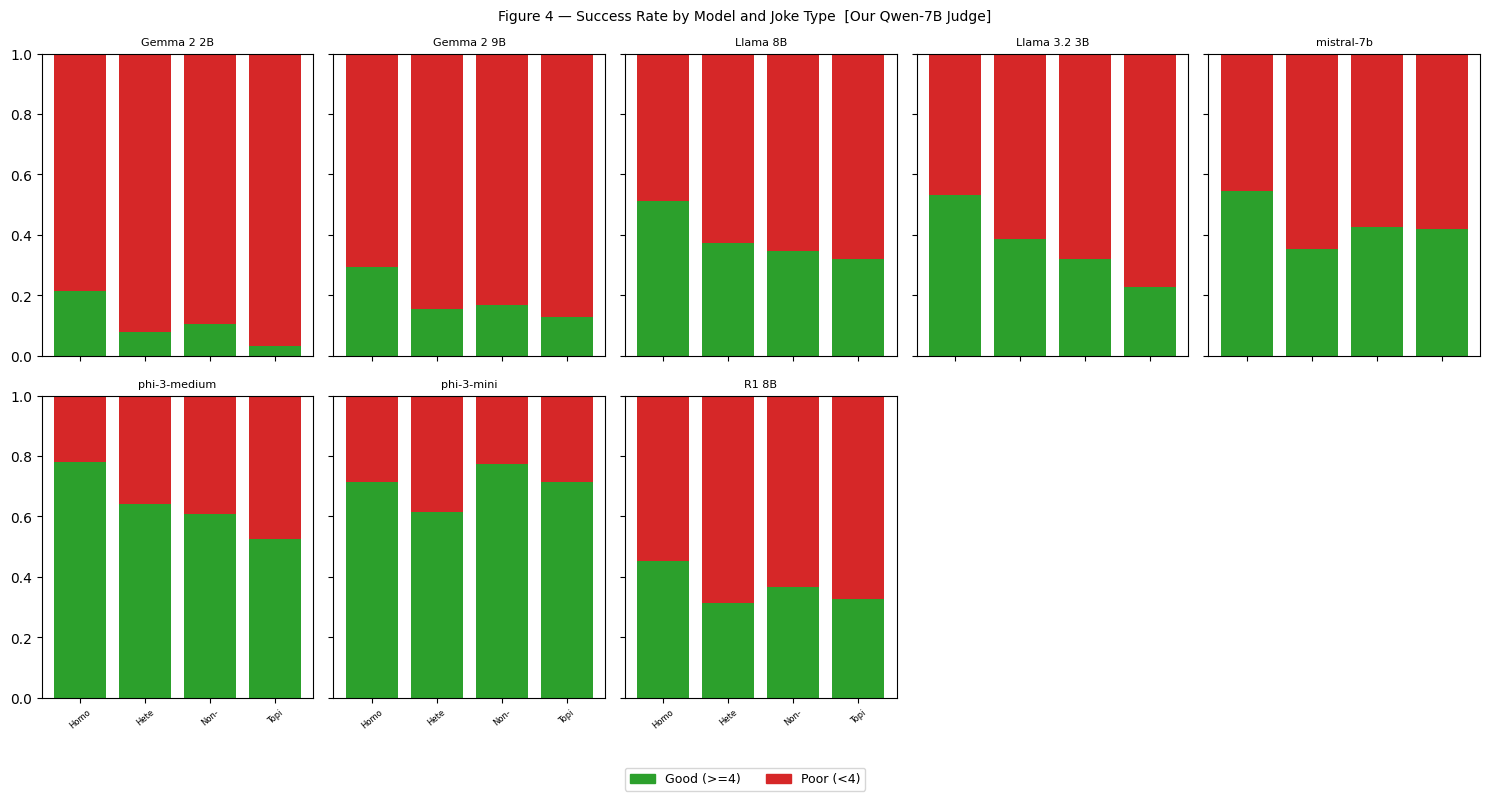

Saved to outputs/fig4_our_judge.png


In [11]:
# Figure 4 — Success rate grid
# Reads models dynamically from your ratings — no hardcoded model list.
%matplotlib inline
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
import numpy as np

JOKE_TYPE_ORDER  = ["homographic", "heterographic", "non_topical", "topical"]
JOKE_TYPE_LABELS = {"homographic": "Homographic", "heterographic": "Heterographic",
                    "non_topical": "Non-Topical",  "topical": "Topical"}

# Label map — covers your 5 models + paper models if you run on paper data too
KNOWN_LABELS = {
    "r1-distill-llama-8b":  "R1-Llama 8B",
    "llama-3.1-8b":         "Llama 3.1 8B",
    "llama-3.2-3b":         "Llama 3.2 3B",
    "gemma-2-2b":           "Gemma 2 2B",
    "gemma-2-9b":           "Gemma 2 9B",
    # paper models kept so this cell also works on ratings_judge_paper.jsonl
    "r1-distill-llama-70b": "R1 70B",      "r1-distill-llama-8b": "R1 8B",
    "gpt-4o":               "GPT-4o",       "gpt-4o-mini":         "GPT-4o Mini",
    "gemini-1.5-pro":       "Gemini Pro",   "gemini-1.5-flash":    "Gemini Flash",
    "llama-3.1-70b":        "Llama 70B",    "llama-3.1-8b":        "Llama 8B",
}

if "df" not in dir() or len(df) == 0:
    print("Run the summary cell above first.")
else:
    piv = df.pivot_table(index=["joke_id", "joke_type", "model"],
                         columns="criterion", values="score", aggfunc="first").reset_index()
    piv.columns.name = None
    piv["is_good"] = (piv["accuracy"] >= 4) & (piv["completeness"] >= 4)
    sr = (piv.groupby(["model", "joke_type"])["is_good"]
             .mean().reset_index().rename(columns={"is_good": "success_rate"}))

    # Derive model list and grid from actual data (no hardcoded list)
    models  = sorted(sr["model"].unique())
    jtypes  = [t for t in JOKE_TYPE_ORDER if t in sr["joke_type"].unique()]
    n       = len(models)
    ncols   = min(n, 5)
    nrows   = (n + ncols - 1) // ncols

    fig, axes = plt.subplots(nrows, ncols,
                              figsize=(3 * ncols, 4 * nrows),
                              sharey=True, sharex=True)
    axes_flat = np.array(axes).flatten()   # 1-D regardless of grid shape

    for ai, m in enumerate(models):
        ax = axes_flat[ai]
        goods = [
            float(sr[(sr["model"]==m) & (sr["joke_type"]==jt)]["success_rate"].iloc[0])
            if len(sr[(sr["model"]==m) & (sr["joke_type"]==jt)]) else 0
            for jt in jtypes
        ]
        x = np.arange(len(jtypes))
        ax.bar(x, goods, color="#2ca02c")
        ax.bar(x, [1-g for g in goods], bottom=goods, color="#d62728")
        ax.set_title(KNOWN_LABELS.get(m, m), fontsize=8)
        ax.set_xticks(x)
        ax.set_xticklabels([JOKE_TYPE_LABELS[t][:4] for t in jtypes],
                            fontsize=6, rotation=40)
        ax.set_ylim(0, 1)

    # Hide any unused subplots (if n is not a multiple of ncols)
    for ai in range(n, len(axes_flat)):
        axes_flat[ai].set_visible(False)

    fig.legend(handles=[mpatches.Patch(color="#2ca02c", label="Good (>=4)"),
                        mpatches.Patch(color="#d62728", label="Poor (<4)")],
               loc="lower center", ncol=2, fontsize=9)
    fig.suptitle("Figure 4 — Success Rate by Model and Joke Type  [Our Qwen-7B Judge]",
                 fontsize=10)
    fig.tight_layout(rect=[0, 0.06, 1, 1])
    plt.savefig("outputs/fig4_our_judge.png", dpi=150, bbox_inches="tight")
    plt.show()
    print("Saved to outputs/fig4_our_judge.png")

---
## Section 6 — Compare vs Paper's Qwen-72B Baseline

In [12]:
# Pearson r + MAE vs paper's 72B judge
import pandas as pd, numpy as np, json
from pathlib import Path

PAPER_RATINGS = Path("outputs/ratings_judge_paper.jsonl")
OUR_RATINGS   = Path("outputs/ratings_judge.jsonl")

def read_jsonl(p):
    return [json.loads(l) for l in p.open(encoding="utf-8") if l.strip()]

if not OUR_RATINGS.exists() or OUR_RATINGS.stat().st_size == 0:
    print("Run Section 4 first.")
elif not PAPER_RATINGS.exists():
    print("outputs/ratings_judge_paper.jsonl not found.")
else:
    ours   = pd.DataFrame(read_jsonl(OUR_RATINGS)).rename(columns={"score": "score_ours"})
    paper  = pd.DataFrame(read_jsonl(PAPER_RATINGS)).rename(columns={"score": "score_paper"})
    merged = ours.merge(paper[["joke_id", "model", "criterion", "score_paper"]],
                        on=["joke_id", "model", "criterion"], how="inner")

    print(f"Matched rows: {len(merged):,}\n")
    print(f"  {'Criterion':<14} {'Pearson r':>10} {'MAE':>8} {'Exact':>8} {'Within+/-1':>12}")
    print(f"  {'─'*56}")
    for crit in ["accuracy", "completeness"]:
        sub = merged[merged["criterion"] == crit]
        r       = sub["score_ours"].corr(sub["score_paper"])
        mae     = (sub["score_ours"] - sub["score_paper"]).abs().mean()
        exact   = (sub["score_ours"] == sub["score_paper"]).mean()
        within1 = ((sub["score_ours"] - sub["score_paper"]).abs() <= 1).mean()
        print(f"  {crit.capitalize():<14} {r:>10.3f} {mae:>8.3f} {exact:>8.1%} {within1:>12.1%}")
    print()
    print("  Paper Qwen-72B vs human: r=0.641/0.602  (our 7B will be lower — expected)")

Matched rows: 2,400

  Criterion       Pearson r      MAE    Exact   Within+/-1
  ────────────────────────────────────────────────────────
  Accuracy            0.244    0.718    47.2%        86.7%
  Completeness        0.291    0.654    46.3%        90.2%

  Paper Qwen-72B vs human: r=0.641/0.602  (our 7B will be lower — expected)


  Criterion        Binary agree  Cohen kappa
  ────────────────────────────────────────────
  Accuracy                64.1%        0.221
  Completeness            64.5%        0.273

  kappa: >0.2 fair, >0.4 moderate, >0.6 substantial
  Paper reports kappa=0.565/0.519 for Qwen-72B vs human.


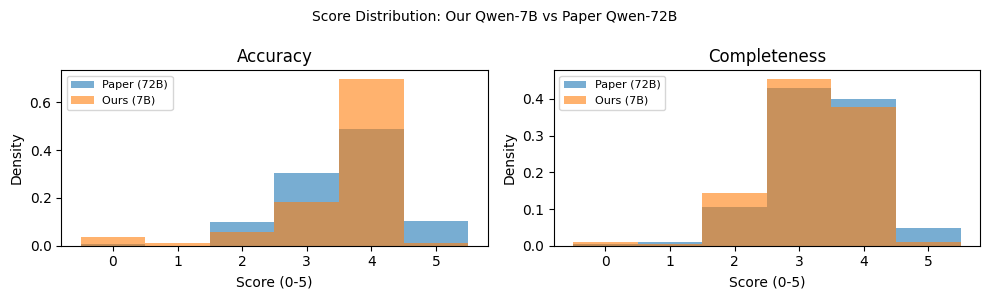

Saved to outputs/judge_comparison.png


In [13]:
# Cohen's kappa + score distribution plot
from sklearn.metrics import cohen_kappa_score

if "merged" not in dir() or len(merged) == 0:
    print("Run the cell above first.")
else:
    print(f"  {'Criterion':<14} {'Binary agree':>14} {'Cohen kappa':>12}")
    print(f"  {'─'*44}")
    for crit in ["accuracy", "completeness"]:
        sub = merged[merged["criterion"] == crit].copy()
        sub["pass_ours"]  = (sub["score_ours"]  >= 4).astype(int)
        sub["pass_paper"] = (sub["score_paper"] >= 4).astype(int)
        agree = (sub["pass_ours"] == sub["pass_paper"]).mean()
        kappa = cohen_kappa_score(sub["pass_paper"], sub["pass_ours"])
        print(f"  {crit.capitalize():<14} {agree:>14.1%} {kappa:>12.3f}")
    print()
    print("  kappa: >0.2 fair, >0.4 moderate, >0.6 substantial")
    print("  Paper reports kappa=0.565/0.519 for Qwen-72B vs human.")

    fig, axes = plt.subplots(1, 2, figsize=(10, 3))
    for ax, crit in zip(axes, ["accuracy", "completeness"]):
        sub  = merged[merged["criterion"] == crit]
        bins = np.arange(-0.5, 6, 1)
        ax.hist(sub["score_paper"], bins=bins, alpha=0.6, label="Paper (72B)", density=True)
        ax.hist(sub["score_ours"],  bins=bins, alpha=0.6, label="Ours (7B)",   density=True)
        ax.set_title(crit.capitalize())
        ax.set_xlabel("Score (0-5)")
        ax.set_ylabel("Density")
        ax.legend(fontsize=8)
        ax.set_xticks(range(6))
    fig.suptitle("Score Distribution: Our Qwen-7B vs Paper Qwen-72B", fontsize=10)
    fig.tight_layout()
    plt.savefig("outputs/judge_comparison.png", dpi=150)
    plt.show()
    print("Saved to outputs/judge_comparison.png")